In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import pandas as pd

df = pd.read_csv(r"D:\Jupyter Notebook\Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print(df.shape)

(9994, 21)


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
# TOP SELLING PRODUCTS
top_products = df.groupby("Product Name")["Sales"].sum()

top_products = top_products.sort_values(ascending=False)

top_products.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

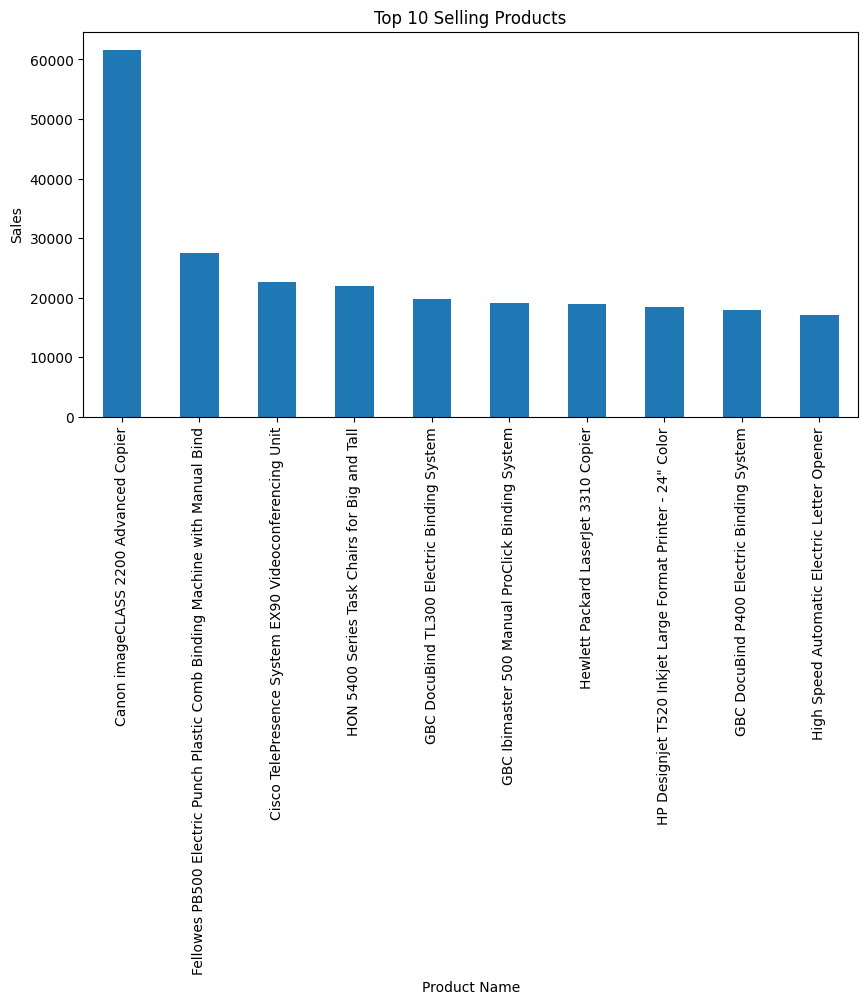

In [6]:
top10 = top_products.head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.ylabel("Sales")
plt.show()

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [8]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [9]:
# MONTHLY REVENUE TREND
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.head()

Month
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

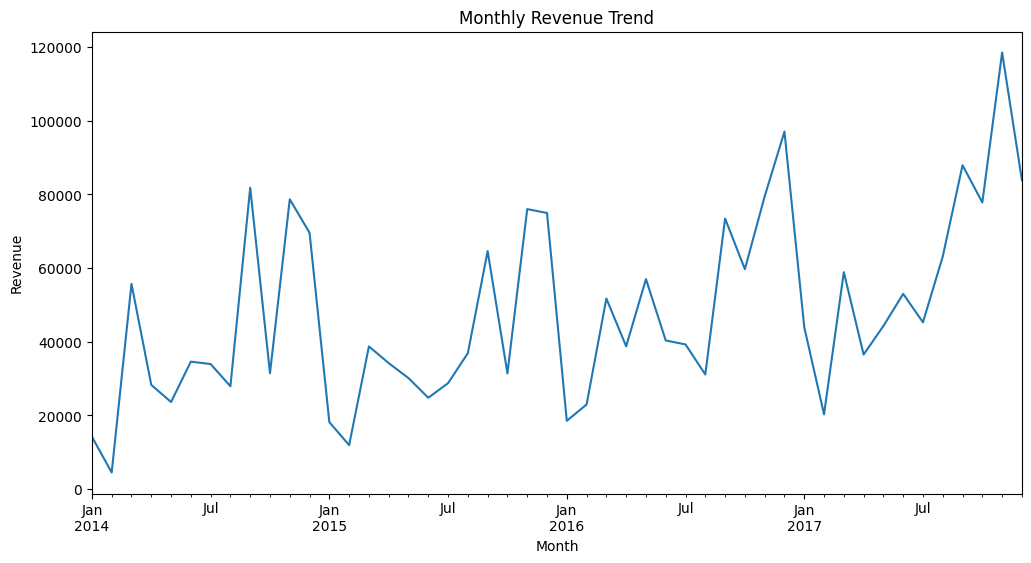

In [10]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [11]:
# CUSTOMER SEGMENTATION
customer_sales = df.groupby("Customer Name")["Sales"].sum()
customer_sales.head()

Customer Name
Aaron Bergman       886.156
Aaron Hawkins      1744.700
Aaron Smayling     3050.692
Adam Bellavance    7755.620
Adam Hart          3250.337
Name: Sales, dtype: float64

In [ ]:
customer_segment = pd.qcut(
    customer_sales,
    q=3,
    labels=["Low Value","Medium Value","High Value"]
)
customer_segment.head()

In [13]:
customer_segment.value_counts()

Sales
Low Value       265
High Value      265
Medium Value    263
Name: count, dtype: int64

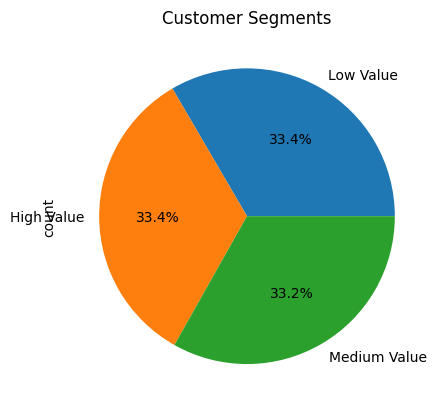

In [14]:
customer_segment.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Customer Segments")

plt.show()

In [15]:
top_products.to_csv("Top_Products.csv")

monthly_sales.to_csv("Monthly_Sales.csv")

customer_segment.to_csv("Customer_Segments.csv")